In [19]:
#imports
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
#Load data
df=pd.read_csv("../data/processed/cleaned_house_data_ds.csv")
df.head()

,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,495000,1527,2,1.5,Suburb,1956,Good
1,752000,2526,3,2.5,Downtown,1998,Excellent
2,319000,1622,2,1.5,Rural,1975,Fair
3,1210000,3102,4,3.0,Waterfront,2005,Excellent
4,462000,1835,2,2.0,Urban,1982,Good


In [ ]:
#Feature engineering
#HOUSE AGE
df["house_age"]=datetime.now().year-df["year_built"]
#PRICE PER SQFT (I created this feature just for curiosity, but a won't add to the model later.)
df["price_per_sqft"]=df["price"]/df["sqft"]
#bed_badt
df["bed_bath_ratio"]=df["bedrooms"]/df["bathrooms"]
df["bed_bath_ratio"]=df["bed_bath_ratio"].replace([np.inf,-np.inf],np.nan).fillna(0)
df.head()
df.describe()

,price,sqft,bedrooms,bathrooms,year_built,house_age,price_per_sqft,bed_bath_ratio
count,8.400000e+01,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.285595e+05,2191.500000,2.857143,2.190476,1982.047619,43.952381,268.090387,1.362519
std,3.591678e+05,650.017117,0.852252,0.828356,19.501563,19.501563,67.742970,0.262230
min,2.490000e+05,1350.000000,2.000000,1.000000,1947.000000,7.000000,179.761905,1.000000
25%,3.742500e+05,1695.000000,2.000000,1.500000,1965.000000,30.500000,229.436507,1.200000
50%,5.110000e+05,1995.000000,3.000000,2.000000,1982.500000,43.500000,254.326923,1.333333
75%,7.292500e+05,2590.000000,3.000000,2.500000,1995.500000,61.000000,279.782904,1.500000
max,1.680000e+06,3850.000000,5.000000,4.500000,2019.000000,79.000000,436.363636,2.000000


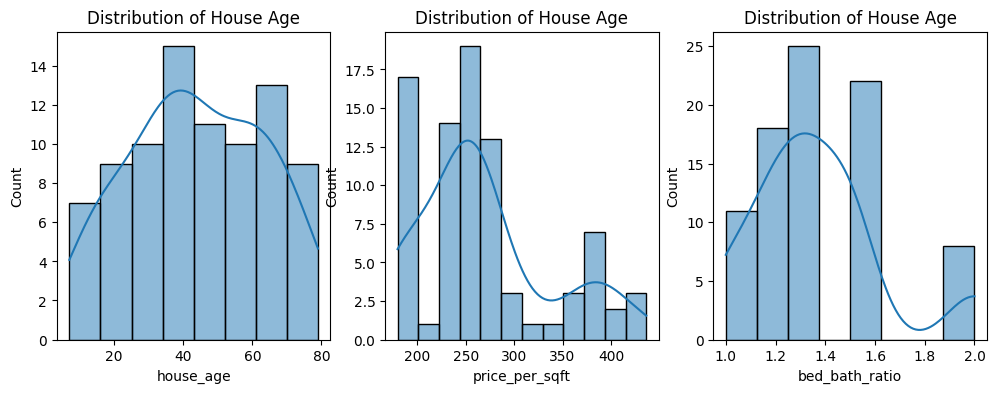

In [22]:
#Plot distribution for new features
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(12,4))

sns.histplot(df["house_age"],kde=True,ax=axes[0])
axes[0].set_title("Distribution of House Age")

sns.histplot(df["price_per_sqft"],kde=True,ax=axes[1])
axes[1].set_title("Distribution of House Age")

sns.histplot(df["bed_bath_ratio"],kde=True,ax=axes[2])
axes[2].set_title("Distribution of House Age")

plt.show()

In [24]:
#Save featured data
df.head()
df.to_csv("../data/processed/featured_house_data_ds.csv",index=False)